# Genetic-algorithm XGBoost — Regression Demo

This notebook evolves an **XGBoost regressor** with `genetic_xgb.GeneticXGBRegressor`, the same
genetic algorithm used for classification but optimizing a continuous target.

Each individual carries a **genome** (hyperparameters) and a **phenotype** (its warm-started
booster). Over generations the population improves through evaluate-fitness → selection →
crossover → mutation → stopping. Here fitness is **validation RMSE** (lower is better).

We also enable XGBoost **built-in early stopping**: with `early_stopping_rounds` set and
`step_rounds` larger, each member stops adding trees once validation stops improving.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

from genetic_xgb import GeneticXGBRegressor

## 1. Data

The real `load_diabetes` dataset (442 rows, 10 features), split into train / validation /
held-out test.

In [2]:
data = load_diabetes()
X = data.data.astype(np.float32)
y = data.target.astype(np.float32)

X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, random_state=0)
print(f"train={X_train.shape}  val={X_val.shape}  test={X_test.shape}")

train=(264, 10)  val=(89, 10)  test=(89, 10)


## 2. Configure and run the regressor

`metric="rmse"` drives selection; early stopping caps each member's per-generation growth.

In [3]:
reg = GeneticXGBRegressor(
    population_size=12,
    metric="rmse",  # rmse | mae | mse | r2 | callable
    selection_top_k=4,
    dominance_prob=0.7,
    mutation_fraction=0.3,
    mutation_intensity=0.2,
    generations=12,
    step_rounds=60,  # upper bound per generation...
    early_stopping_rounds=10,  # ...early stopping trims it on plateau
    n_jobs=-1,
    random_state=0,
)
# X_val / y_val (and sample_weight) are keyword-only.
reg.fit(X_train, y_train, X_val=X_val, y_val=y_val)
print(f"best validation RMSE: {reg.best_score_:.3f}")

best validation RMSE: 57.693


## 3. RMSE across generations

Best validation RMSE should fall as the population adapts.

In [4]:
best_per_gen = reg.history_.groupby("generation")["score"].min()
best_per_gen

generation
0     60.953355
1     58.452484
2     58.155805
3     58.024232
4     57.693450
5     57.774838
6     57.779463
7     57.709458
8     57.710736
9     57.711322
10    57.711371
11    57.713372
Name: score, dtype: float64

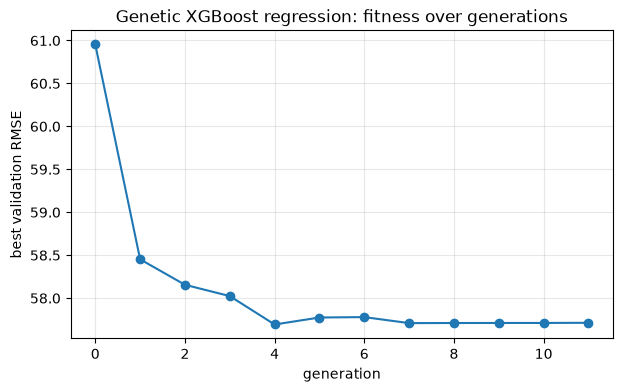

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(best_per_gen.index, best_per_gen.values, marker="o")
ax.set_xlabel("generation")
ax.set_ylabel("best validation RMSE")
ax.set_title("Genetic XGBoost regression: fitness over generations")
ax.grid(True, alpha=0.3)
plt.show()

## 4. The fittest individual

In [6]:
print(f"best_score_ (validation RMSE): {reg.best_score_:.3f}")
pd.Series(reg.best_params_, name="value").to_frame()

best_score_ (validation RMSE): 57.693


,value
learning_rate,1.021629e-01
max_depth,6.000000e+00
min_child_weight,2.068326e+00
gamma,7.995865e-02
subsample,1.000000e+00
colsample_bytree,6.330651e-01
colsample_bylevel,7.694672e-01
colsample_bynode,7.213764e-01
max_delta_step,9.310173e+00
reg_alpha,1.980990e-08


## 5. Held-out test performance

In [7]:
preds = reg.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, preds))
test_r2 = r2_score(y_test, preds)
print(f"held-out test RMSE: {test_rmse:.3f}")
print(f"held-out test R^2 : {test_r2:.3f}")
print(f"prediction shape  : {preds.shape} (continuous)")

held-out test RMSE: 61.109
held-out test R^2 : 0.272
prediction shape  : (89,) (continuous)


## 6. Lineage and early-stopping insight

`history_` records every individual per generation, including `best_iteration` (where early
stopping found the best round) and `parents` (which two parents bred each offspring).

In [8]:
print(f"history_: {len(reg.history_)} rows")
reg.history_[["generation", "member_id", "score", "n_rounds", "best_iteration", "parents"]].head(12)

history_: 144 rows


,generation,member_id,score,n_rounds,best_iteration,parents
0,0,0,73.468723,60,59,None
1,0,1,78.923841,60,59,None
2,0,2,71.049677,60,59,None
3,0,3,73.808134,60,59,None
4,0,4,76.873145,60,59,None
5,0,5,78.680910,60,59,None
6,0,6,78.607277,60,59,None
7,0,7,60.953355,50,39,None
8,0,8,78.954821,60,59,None
9,0,9,61.399242,60,59,None
